In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
import zipfile
import os

# Extract the zip
with zipfile.ZipFile("archive.zip", "r") as z:
    z.extractall(".")
    print("Extracted:", z.namelist())

print("Files now:", os.listdir())

Extracted: ['car data.csv']
Files now: ['.config', 'car data.csv', 'archive.zip', 'sample_data']


In [7]:
df = pd.read_csv("car data.csv")
print("Shape:", df.shape)
print(df.head())
print(df.describe())

Shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       

In [8]:
df['Car_Age'] = 2024 - df['Year']

le = LabelEncoder()
df['Fuel_Type_enc']    = le.fit_transform(df['Fuel_Type'])
df['Selling_type_enc'] = le.fit_transform(df['Selling_type'])
df['Transmission_enc'] = le.fit_transform(df['Transmission'])

features = ['Present_Price', 'Driven_kms', 'Fuel_Type_enc',
            'Selling_type_enc', 'Transmission_enc', 'Owner', 'Car_Age']

X = df[features]
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (240, 7) | Test size: (61, 7)


✅ R² Score : 0.8467
✅ RMSE     : 1.8792


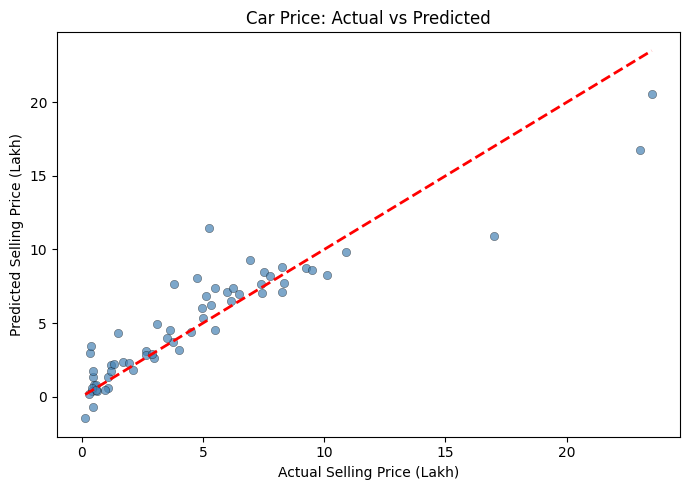

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"✅ R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"✅ RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Selling Price (Lakh)")
plt.ylabel("Predicted Selling Price (Lakh)")
plt.title("Car Price: Actual vs Predicted")
plt.tight_layout()
plt.show()

/tmp/ipykernel_10883/4132115496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='Blues_r')


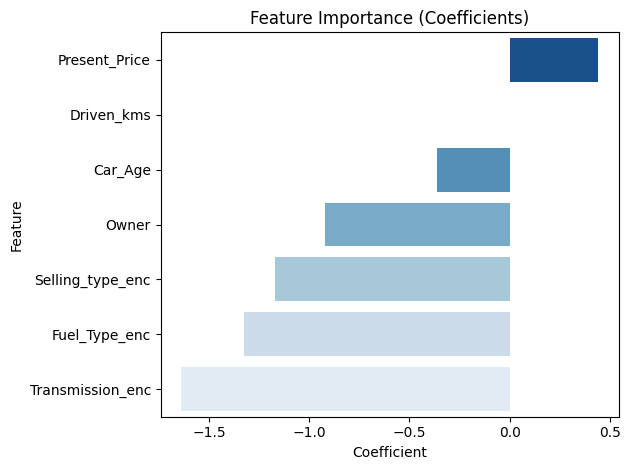

In [10]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='Blues_r')
plt.title("Feature Importance (Coefficients)")
plt.tight_layout()
plt.show()